<a href="https://colab.research.google.com/github/abhsrivastava/hugging_face_transformers/blob/main/HuggingFace_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies

%pip install -q transformers torch torchvision torchaudio huggingface_hub Pillow


In [3]:
from huggingface_hub import list_models
from transformers import pipeline
from PIL import Image
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete! All packages installed and imported.")

✅ Setup complete! All packages installed and imported.


In [3]:
# load the hugging face tokens
from google.colab import userdata
hf_token = userdata.get("HF_TOKEN")

from huggingface_hub import login
login(token=hf_token)


In [4]:
# Search for Text Classifiction Models and sort them by downloads

models = list_models(
    pipeline_tag="text-classification",
    sort="downloads",
    limit = 5)
print("=== Top 5 Text Classification Models ===")
for m in models:
  print(f"  {m.id} | Downloads: {m.downloads}")


=== Top 5 Text Classification Models ===
  BAAI/bge-reranker-v2-m3 | Downloads: 19095387
  ProsusAI/finbert | Downloads: 6080783
  BAAI/bge-reranker-base | Downloads: 4927152
  meta-llama/Prompt-Guard-86M | Downloads: 4485805
  distilbert/distilbert-base-uncased-finetuned-sst-2-english | Downloads: 3623616


In [15]:
# Search for best image classification models

models = list_models(
    pipeline_tag="image-classification",
    sort="downloads",
    limit = 5)
print("=== Top 5 Image Classification Models ===")
for m in models:
  print(f"  {m.id} | Downloads: {m.downloads}")

=== Top 5 Image Classification Models ===
  timm/mobilenetv3_small_100.lamb_in1k | Downloads: 18577051
  Falconsai/nsfw_image_detection | Downloads: 6560718
  google/vit-base-patch16-224 | Downloads: 4603748
  dima806/fairface_age_image_detection | Downloads: 4296520
  timm/resnet50.a1_in1k | Downloads: 3116459


In [5]:
# Search for Automatic Speech Recognition Models
models = list_models(
    pipeline_tag="automatic-speech-recognition",
    sort="downloads",
    limit = 5
)
print("===Top 5 Automatic Speech Recognition Models ===")
for m in models:
  print(f". {m.id} | Downloads: {m.downloads}")


===Top 5 Automatic Speech Recognition Models ===
. pyannote/speaker-diarization-3.1 | Downloads: 8828060
. openai/whisper-large-v3-turbo | Downloads: 8616744
. argmaxinc/whisperkit-coreml | Downloads: 7919751
. openai/whisper-base | Downloads: 5983304
. openai/whisper-large-v3 | Downloads: 5855853


In [21]:
# Create a model evaluation template

evaluation = {
    "text_classification": {
        "model_id": "distilbert-base-uncased-finetuned-sst-2-english",
        "task_type": "text_classification",
        "license": "",
        "rationale": ""
    },
    "image_classification": {
        "model_id": "openai/clip-vit-base-patch32",
        "task_type": "image_classification",
        "license": "",
        "rationale": ""
    },
    "speech_recognition": {
        "model_id": "openai/whisper-tiny",
        "task_type": "automatic-speech-recognition",
        "license": "",
        "rationale": ""
    }
}

# print the evaluation template
for use_case, info in evaluation.items():
  print(f"=== {use_case} ===")
  for key, value in info.items():
    print(f"{key}: {value}")



=== text_classification ===
model_id: distilbert-base-uncased-finetuned-sst-2-english
task_type: text_classification
license: 
rationale: 
=== image_classification ===
model_id: openai/clip-vit-base-patch32
task_type: image_classification
license: 
rationale: 
=== speech_recognition ===
model_id: openai/whisper-tiny
task_type: automatic-speech-recognition
license: 
rationale: 


In [5]:
# Run Text classification

novapay_messages = [
  "My payment was declined and I need help immediately!",
  "Love the new app design, very intuitive and clean.",
  "I've been waiting 3 days for my refund. This is unacceptable.",
  "Can you explain the fee structure for international transfers?",
  "Your customer service team was incredibly helpful today, thank you!"
  ]
classifier = pipeline("text-classification", model=evaluation["text_classification"]["model_id"])
print("✅ Text classification pipeline loaded!")
classification_results = classifier(novapay_messages)
#display results
print("=== Text Classification Results ===")
for msg, result in zip(novapay_messages, classification_results):
  print(f"\n  Message:    {msg}")
  print(f"  Label:      {result['label']}")
  print(f"  Confidence: {result['score']:.4f}")


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

✅ Text classification pipeline loaded!
=== Text Classification Results ===

  Message:    My payment was declined and I need help immediately!
  Label:      NEGATIVE
  Confidence: 0.9944

  Message:    Love the new app design, very intuitive and clean.
  Label:      POSITIVE
  Confidence: 0.9999

  Message:    I've been waiting 3 days for my refund. This is unacceptable.
  Label:      NEGATIVE
  Confidence: 0.9998

  Message:    Can you explain the fee structure for international transfers?
  Label:      NEGATIVE
  Confidence: 0.9928

  Message:    Your customer service team was incredibly helpful today, thank you!
  Label:      POSITIVE
  Confidence: 0.9998


Sample product image loaded successfully!
Image size: (250, 187)


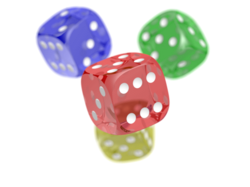

In [19]:
# Load the Test Image

image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/250px-PNG_transparency_demonstration_1.png"
response = requests.get(image_url, headers={"User-Agent": "HuggingFace-Colab-Tutorial/1.0"}
)
transparent_image = Image.open(BytesIO(response.content)).convert("RGBA")
background = Image.new("RGBA", transparent_image.size, "white")
sample_image = Image.alpha_composite(background, transparent_image).convert("RGB")

# Display the image
print("Sample product image loaded successfully!")
print(f"Image size: {sample_image.size}")
display(sample_image)


In [22]:
# Run Image classifier on loaded image

image_classifier = pipeline("zero-shot-image-classification", model=evaluation["image_classification"]["model_id"])
image_results = image_classifier(
    sample_image,
    candidate_labels=["golf ball", "salt shaker", "guitar pick", "dice"])
print("=== Image Classification Results (Top 3) ===")
for i, result in enumerate(image_results, 1):
  print(f"  {i}. {result['label']} — Confidence: {result['score']:.4f}")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

=== Image Classification Results (Top 3) ===
  1. dice — Confidence: 0.9996
  2. golf ball — Confidence: 0.0003
  3. guitar pick — Confidence: 0.0001
  4. salt shaker — Confidence: 0.0000
